### Name : Bhogaraju Shanmukha Sri Krishna
### Roll No: 112201013
### B.Tech 4th Year CSE

In [3]:
print("Hello world")

Hello world


In [4]:
import pandas as pd
import numpy as np

from scipy import stats
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score
)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA

from matplotlib import pyplot as plt


### Reading data and preprocessing

In [5]:
columns = (['duration'
,'protocol_type'
,'service'
,'flag'
,'src_bytes'
,'dst_bytes'
,'land'
,'wrong_fragment'
,'urgent'
,'hot'
,'num_failed_logins'
,'logged_in'
,'num_compromised'
,'root_shell'
,'su_attempted'
,'num_root'
,'num_file_creations'
,'num_shells'
,'num_access_files'
,'num_outbound_cmds'
,'is_host_login'
,'is_guest_login'
,'count'
,'srv_count'
,'serror_rate'
,'srv_serror_rate'
,'rerror_rate'
,'srv_rerror_rate'
,'same_srv_rate'
,'diff_srv_rate'
,'srv_diff_host_rate'
,'dst_host_count'
,'dst_host_srv_count'
,'dst_host_same_srv_rate'
,'dst_host_diff_srv_rate'
,'dst_host_same_src_port_rate'
,'dst_host_srv_diff_host_rate'
,'dst_host_serror_rate'
,'dst_host_srv_serror_rate'
,'dst_host_rerror_rate'
,'dst_host_srv_rerror_rate'
,'attack'
,'level'])

In [6]:
%pip install pandas numpy scipy
%pip install scikit-learn
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Training data
df = pd.read_csv("data/KDDTrain+.txt")
df.columns = columns
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.0,0.00,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.0,0.00,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.0,0.01,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.07,0.07,0.00,0.00,0.00,0.00,1.0,1.00,neptune,21


In [8]:
# Training the anomaly detection model only on 'normal' data points

df_train = df[df["attack"] == "normal"]

X_train = df_train.drop(columns=["attack"])
X_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,level
0,0,udp,other,SF,146,0,0,0,0,0,...,1,0.0,0.6,0.88,0.00,0.00,0.00,0.0,0.00,15
2,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.0,0.0,0.03,0.04,0.03,0.01,0.0,0.01,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.0,0.0,0.00,0.00,0.00,0.00,0.0,0.00,21
11,0,tcp,http,SF,287,2251,0,0,0,0,...,219,1.0,0.0,0.12,0.03,0.00,0.00,0.0,0.00,21
15,0,tcp,http,SF,300,13788,0,0,0,0,...,255,1.0,0.0,0.01,0.02,0.00,0.00,0.0,0.00,21


In [9]:
# Testing data

df_test = pd.read_csv('./data/KDDTest+.txt')
df_test.columns = columns

In [10]:
# Using Column Transformer to properly transform the cols of df

num_features = X_train.select_dtypes(include='number').columns.to_list()
cat_features = X_train.select_dtypes(exclude='number').columns.to_list()


preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown = 'ignore'), cat_features)
    ]
)

#### Preprocessing the train and test data

In [11]:
X_train_processed = preprocessor.fit_transform(X_train)
X_train_processed

array([[-0.12924194, -0.03106209, -0.06614059, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12924194, -0.0308564 ,  0.05840339, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12924194, -0.03093533, -0.05972474, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.12310909, -0.03116015, -0.0639256 , ...,  0.        ,
         1.        ,  0.        ],
       [-0.12924194, -0.0260754 , -0.06027467, ...,  0.        ,
         1.        ,  0.        ],
       [-0.12924194, -0.03105013, -0.06614059, ...,  0.        ,
         1.        ,  0.        ]], shape=(67342, 78))

In [12]:
X_test = df_test.drop(columns = ['attack'])
X_test_processed = preprocessor.transform(X_test)
X_test_processed

array([[-1.29241937e-01, -3.14112762e-02, -6.61405942e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-1.27708727e-01, -3.59871653e-04, -6.61405942e-02, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-1.29241937e-01, -3.13634423e-02, -6.61405942e-02, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       ...,
       [-1.29241937e-01,  9.90318883e-02,  6.08628035e-02, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-1.29241937e-01, -3.13108249e-02, -6.54990086e-02, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       [-1.29241937e-01, -3.14112762e-02, -6.61405942e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(22543, 78))

#### Using PCA for dimensionality reduction

In [13]:
pca = PCA(0.95)  # retain 95% variance
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

### Training the main classifier to get the probability distribution

In [14]:
### Cell 2 editing

# create a multivariate distribution given our means and standard deviations
mu = X_train_pca.mean(axis = 0)
sig = np.cov(X_train_pca, rowvar = False)
sig += 1e-6 * np.eye(sig.shape[0])   # regularization to avoid singular cov matrix


dist = stats.multivariate_normal(mu, sig)

# calculate probability density values for our features for ALL values
proba = dist.logpdf(X_train_pca)

### Testing the model

In [15]:
# Testing data's labels

y_true = np.where(df_test['attack'] == 'normal', 0, 1)

In [16]:
# Since the distribution has many points, using logpdf for better classification

proba = dist.logpdf(X_test_pca)
proba.size

22543

#### Testing for various values of $\epsilon$

In [17]:
eps = np.linspace(-500, -5, 150)

recall = []
precision = []
auc = []
f1 = []

for e in eps:
    y_pred = np.where(proba < e, 0, 1)
    recall.append(recall_score(y_true, y_pred))
    precision.append(precision_score(y_true, y_pred))
    auc.append(roc_auc_score(y_true, y_pred))
    f1.append(f1_score(y_true, y_pred))

/media/shanmukha/DATA1/Acads/Sem_8/AI-for-cybersecurity/lab5-anomaly-detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/shanmukha/DATA1/Acads/Sem_8/AI-for-cybersecurity/lab5-anomaly-detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/media/shanmukha/DATA1/Acads/Sem_8/AI-for-cybersecurity/lab5-anomaly-detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 d

#### Plotting all values of metrics vs $\epsilon$

<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_39976/2992837071.py:10: SyntaxWarning: invalid escape sequence '\e'
  plt.title('Precision & Recall vs $\epsilon$')


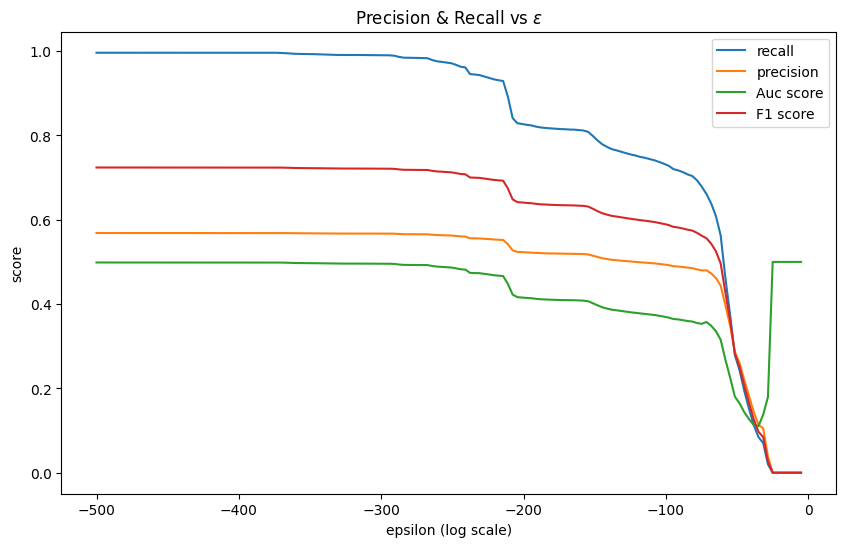

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(eps, recall, label='recall')
plt.plot(eps, precision, label='precision')
plt.plot(eps, auc, label = 'Auc score')
plt.plot(eps, f1, label = 'F1 score')

plt.xlabel('epsilon (log scale)')
plt.ylabel('score')
plt.title('Precision & Recall vs $\epsilon$')
plt.legend()
plt.show()

In [20]:
max(auc), max(f1), max(recall), max(precision)

(0.5, 0.7239621679787054, 0.996181421446384, 0.5685882038964505)